# Exercise 7 - Linear Regression

In this tutorial, we will learn about **linear regression**, a regression algorithm used to predict a **continuous** target variable (unlike classification algorithms, such as the decision tree we used in the previous tutorial, which predict a categorical label).

We will use the `diamonds` dataset (loaded from `data/diamonds.csv`) to predict the `price` of a diamond based on its physical and quality characteristics.

In [1]:
import pandas as pd
import numpy as np

import matplotlib as mpl

import plotnine as pln
import warnings
from plotnine.exceptions import PlotnineWarning
warnings.filterwarnings("ignore", category=PlotnineWarning)

%config InlineBackend.print_figure_kwargs = {'facecolor': 'white', 'bbox_inches': 'tight'}
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['savefig.facecolor'] = 'white'
mpl.rcParams['savefig.transparent'] = False

In [3]:
diamonds = pd.read_csv('data/diamonds.csv', index_col=0)
diamonds

,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


The dataset contains the following columns:

* `carat` - the weight of the diamond
* `cut` - the quality of the cut (ordinal: Fair < Good < Very Good < Premium < Ideal)
* `color` - the diamond color grade (ordinal: J (worst) < I < H < G < F < E < D (best))
* `clarity` - how clear the diamond is (ordinal: I1 (worst) < SI2 < SI1 < VS2 < VS1 < VVS2 < VVS1 < IF (best))
* `depth` - total depth percentage
* `table` - width of the top of the diamond relative to its widest point
* `price` - the price in US dollars (this is our **target** variable)
* `x`, `y`, `z` - length, width and depth in mm

Let's check the shape and data types of the dataset:

In [4]:
diamonds.shape

(53940, 10)

In [5]:
diamonds.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 1 to 53940
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB


So we have 53,940 diamonds and 10 columns. `carat`, `depth`, `table`, `x`, `y`, `z` are numeric, `price` is an integer, and `cut`, `color`, `clarity` are stored as text (categorical).

Let's check whether there are any missing values:

In [6]:
diamonds.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

No missing values - but that doesn't necessarily mean the data is clean. Since `x`, `y` and `z` are physical dimensions (in mm), a value of `0` is impossible for a real diamond, and likely represents missing/bad data that was recorded as `0` instead of `NaN`. Let's check:

In [7]:
bad_rows = diamonds[(diamonds.x == 0) | (diamonds.y == 0) | (diamonds.z == 0)]
bad_rows

,carat,cut,color,clarity,depth,table,price,x,y,z
2208,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,0.0
2315,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,0.0
4792,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,0.0
5472,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,0.0
10168,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,0.0
11183,1.07,Ideal,F,SI2,61.6,56.0,4954,0.00,6.62,0.0
11964,1.00,Very Good,H,VS2,63.3,53.0,5139,0.00,0.00,0.0
13602,1.15,Ideal,G,VS2,59.2,56.0,5564,6.88,6.83,0.0
15952,1.14,Fair,G,VS1,57.5,67.0,6381,0.00,0.00,0.0
24395,2.18,Premium,H,SI2,59.4,61.0,12631,8.49,8.45,0.0


We found 20 diamonds with at least one zero dimension. Since these values are physically impossible, we will drop these rows rather than trying to predict price from clearly invalid measurements:

In [8]:
diamonds = diamonds[(diamonds.x > 0) & (diamonds.y > 0) & (diamonds.z > 0)].reset_index(drop=True)
diamonds.shape

(53920, 10)

Now let's look at some summary statistics of the numeric columns:

In [9]:
diamonds.describe()

,carat,depth,table,price,x,y,z
count,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000
mean,0.797698,61.749514,57.456834,3930.993231,5.731627,5.734887,3.540046
std,0.473795,1.432331,2.234064,3987.280446,1.119423,1.140126,0.702530
min,0.200000,43.000000,43.000000,326.000000,3.730000,3.680000,1.070000
25%,0.400000,61.000000,56.000000,949.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5323.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


## Simple linear regression: price ~ carat

Before using all the predictors together, let's start simple and try to predict `price` using a single predictor: `carat` (the weight of the diamond). Weight is well known to be strongly related to a diamond's price, so it's a natural place to start.

Let's check the correlation between `carat` and `price`:

In [10]:
diamonds[['carat', 'price']].corr()

,carat,price
carat,1.000000,0.921592
price,0.921592,1.000000


A correlation of about **0.92** confirms a strong positive linear relationship. Let's visualize it:

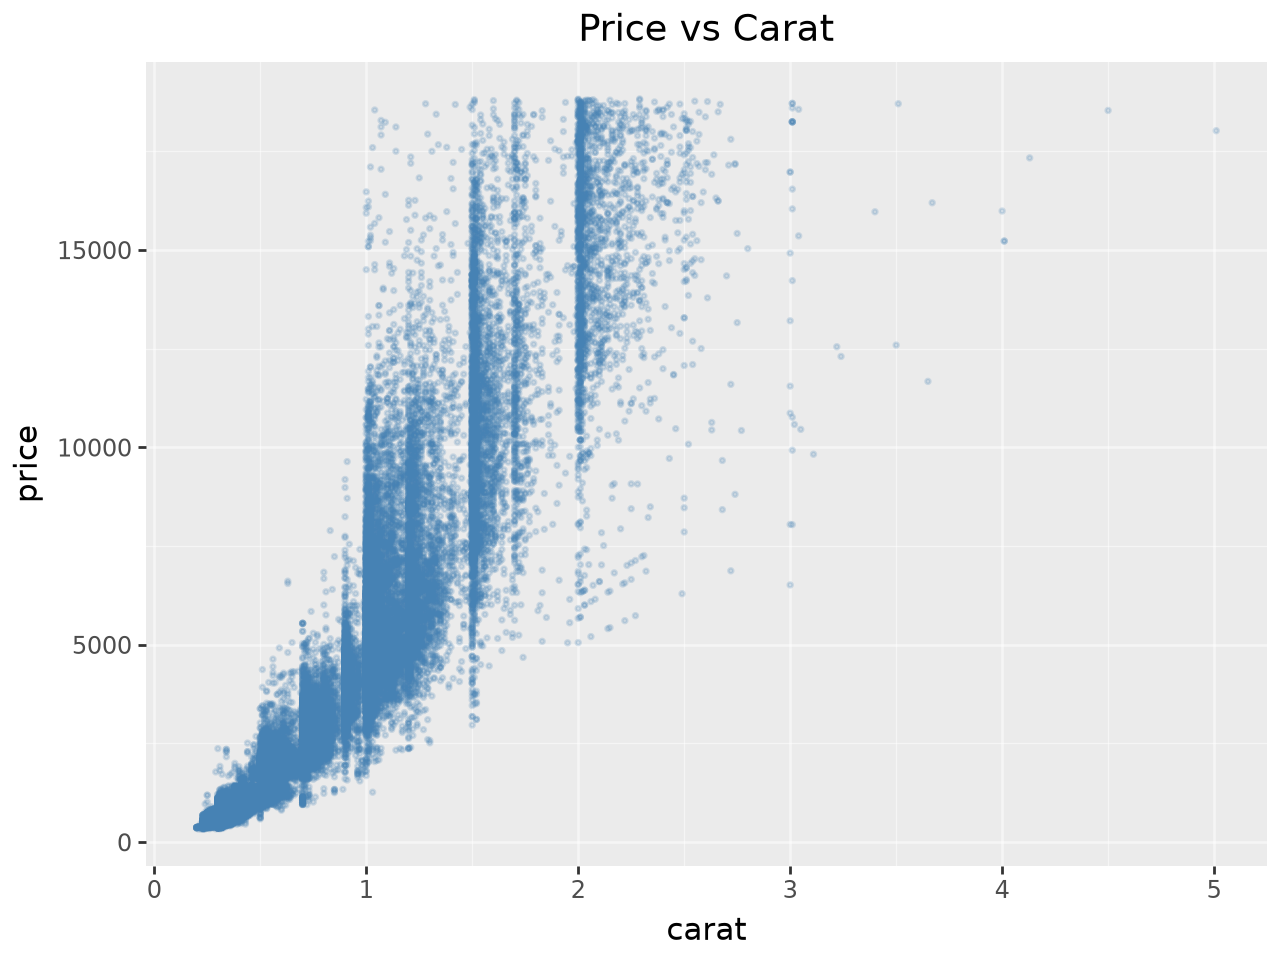

In [11]:
(
    pln.ggplot(diamonds, pln.aes(x='carat', y='price'))
    + pln.geom_point(size=0.5, alpha=0.2, color='steelblue')
    + pln.labs(x='carat', y='price', title='Price vs Carat')
)

Linear regression fits a straight line through the data that minimizes the sum of squared residuals (the vertical distances between the actual points and the line):

$$ \hat{y} = \beta_0 + \beta_1 x $$

where $\beta_0$ is the **intercept** (the predicted price when carat = 0) and $\beta_1$ is the **slope** (how much the predicted price changes for each additional carat).

Let's fit this model using sklearn's `LinearRegression`:

In [12]:
from sklearn.linear_model import LinearRegression

X_simple = diamonds[['carat']]
y = diamonds['price']

simple_model = LinearRegression()
simple_model.fit(X_simple, y)

print(f"Intercept (b0): {simple_model.intercept_:.2f}")
print(f"Slope (b1): {simple_model.coef_[0]:.2f}")

Intercept (b0): -2255.77
Slope (b1): 7755.77


You should get an intercept of about **-2255.77** and a slope of about **7755.77**.

This means that, on average, each additional carat is associated with an increase of about **$7,756** in price. The intercept (-2255.77) doesn't have a meaningful real-world interpretation on its own (a 0-carat diamond doesn't exist, and price can't be negative) - it's simply the value needed to correctly position the line given the range of the data.

Let's plot the fitted line on top of the scatter plot:

In [ ]:
carat_range = pd.DataFrame({'carat': np.linspace(diamonds['carat'].min(), diamonds['carat'].max(), 100)})
carat_range['price'] = simple_model.predict(carat_range)

(
    pln.ggplot()
    + pln.geom_point(diamonds, pln.aes(x='carat', y='price'), size=0.5, alpha=0.2, color='steelblue')
    + pln.geom_line(carat_range, pln.aes(x='carat', y='price'), color='crimson', size=1)
    + pln.labs(x='carat', y='price', title='Price vs Carat with fitted regression line')
)

The line captures the overall increasing trend, but the points fan out more as carat grows - a single predictor clearly isn't the full picture. Let's now build a model that uses **all** the available predictors.

## Multiple linear regression

`cut`, `color` and `clarity` are categorical, but note that they are not just any categories - they have a natural **order** (e.g. `Ideal` cut is better than `Fair` cut). This kind of variable is called an **ordinal** categorical variable.

Since the categories are ordered, we can encode them as integers that preserve that order (0, 1, 2, ...), instead of using one-hot encoding (which would ignore the ordering and add many extra columns). We define the order explicitly, from worst to best, for each variable:

In [ ]:
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

encoded = diamonds.copy()
encoded['cut'] = pd.Categorical(encoded['cut'], categories=cut_order, ordered=True).codes
encoded['color'] = pd.Categorical(encoded['color'], categories=color_order, ordered=True).codes
encoded['clarity'] = pd.Categorical(encoded['clarity'], categories=clarity_order, ordered=True).codes

encoded.head()

`cut`, `color` and `clarity` are now integers (0 = worst category, increasing to the best category), so they can be used directly as numeric predictors.

Now we define `X` (all predictors) and `y` (the target, `price`), as expected for a regression task:

In [ ]:
X = encoded.drop(columns=['price'])
y = encoded['price']

As in the decision tree tutorial, we split the data into a **training set** (used to fit the model) and a **test set** (used to evaluate it on unseen data):

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Now let's fit a `LinearRegression` model using all the predictors:

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

Let's look at the coefficient the model learned for each predictor, sorted by their magnitude (the size of their effect, regardless of direction):

In [ ]:
coef_table = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_
}).sort_values('coefficient', key=abs, ascending=False).reset_index(drop=True)

coef_table

A few things to notice:

* `carat` has by far the largest positive coefficient (~10,796) - a one-carat increase is associated with roughly $10,796 more in price, holding the other predictors fixed.
* `clarity`, `color` and `cut` all have modest **positive** coefficients, which matches our intuition: moving up one level on any of these ordinal scales (towards a better grade) increases the predicted price, all else being equal.
* `x` and `z` have **negative** coefficients, even though they are physical size measurements that should intuitively increase price. This is a classic symptom of **multicollinearity**: `carat`, `x`, `y` and `z` are all strongly correlated with each other (they all essentially measure the size of the diamond), so the model has trouble telling their individual effects apart, and can assign them unstable or even counter-intuitive coefficients - even though the model's overall *predictions* are still accurate. We'll revisit this at the end of the tutorial.

## Evaluating the model

Now let's predict on the test set and see how well the model performs on data it hasn't seen:

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R^2:  {r2:.3f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")

You should get an R² of about **0.910**, RMSE of about **1201**, and MAE of about **790**. Here's what each metric means:

* **R² (coefficient of determination)** - the proportion of the variance in `price` that is explained by the model. It ranges up to 1 (a perfect model); our R² of 0.91 means the model explains about 91% of the variability in diamond prices.
* **RMSE (root mean squared error)** - the square root of the average squared difference between predicted and actual price, in the same units as `price` (dollars). It penalizes large errors more heavily than small ones.
* **MAE (mean absolute error)** - the average absolute difference between predicted and actual price, in dollars. Easier to interpret directly: on average, our predictions are off by about $790.

Let's visualize predicted vs. actual prices:

In [ ]:
pred_df = pd.DataFrame({'actual': y_test.values, 'predicted': y_pred})

(
    pln.ggplot(pred_df, pln.aes(x='actual', y='predicted'))
    + pln.geom_point(size=0.5, alpha=0.2, color='steelblue')
    + pln.geom_abline(slope=1, intercept=0, color='crimson', size=1)
    + pln.labs(x='Actual price', y='Predicted price', title='Predicted vs Actual price')
)

If the model were perfect, every point would fall exactly on the red diagonal line ($\hat{y} = y$). Here, the points hug the line reasonably well for lower-priced diamonds, but spread out more for expensive ones - the model is less precise for high-priced diamonds.

We can look at this more directly with a **residual plot** (residual = actual - predicted), which helps us check whether the errors behave randomly around 0, as a good model's errors should:

In [ ]:
residuals = y_test - y_pred
resid_df = pd.DataFrame({'predicted': y_pred, 'residual': residuals.values})

(
    pln.ggplot(resid_df, pln.aes(x='predicted', y='residual'))
    + pln.geom_point(size=0.5, alpha=0.2, color='steelblue')
    + pln.geom_hline(yintercept=0, color='crimson', size=1)
    + pln.labs(x='Predicted price', y='Residual (actual - predicted)', title='Residual plot')
)

Ideally, residuals should be scattered randomly around 0 with roughly constant spread (this is called **homoscedasticity**). Here, instead, the spread of residuals clearly grows as predicted price increases - a "fan" shape. This means the model's errors are **heteroscedastic**: it's less reliable for expensive diamonds than for cheap ones. This is a common finding for price data, and it's usually worth trying a transformation of the target (e.g. predicting `log(price)` instead of `price`) - that's beyond the scope of this tutorial, but good to keep in mind.

## Dealing with multicollinearity: Ridge regression

Earlier we saw that `carat`, `x`, `y` and `z` are highly correlated with each other, which made some of our model's coefficients (like `x` and `z`) unstable and hard to interpret. **Ridge regression** addresses this by adding a penalty on the size of the coefficients to the loss function the model minimizes:

$$ \text{Loss} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p}\beta_j^2 $$

The extra term $\alpha \sum \beta_j^2$ shrinks the coefficients towards zero, which reduces their sensitivity to multicollinearity (at the cost of introducing a small amount of bias). `alpha` is a **hyperparameter** that controls how strong this shrinkage is: `alpha=0` is equivalent to ordinary linear regression, while larger values shrink the coefficients more aggressively.

As with `max_depth` for the decision tree, we can use `GridSearchCV` to find a good value of `alpha` via cross-validation on the training set:

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}

ridge_search = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    cv=5,
    scoring='r2'
)
ridge_search.fit(X_train, y_train)

best_ridge = ridge_search.best_estimator_
print("Best alpha:", ridge_search.best_params_)
print(f"Best CV R^2: {ridge_search.best_score_:.3f}")

The search should select `alpha=100` as the best value, with a cross-validated R² of about **0.899**. Let's evaluate this tuned model on the test set and compare it to our original (unregularized) linear regression:

In [ ]:
y_pred_ridge = best_ridge.predict(X_test)

print(f"Ridge  R^2: {r2_score(y_test, y_pred_ridge):.3f}   RMSE: {root_mean_squared_error(y_test, y_pred_ridge):.2f}")
print(f"OLS    R^2: {r2_score(y_test, y_pred):.3f}   RMSE: {root_mean_squared_error(y_test, y_pred):.2f}")

The two models perform almost identically on the test set. This makes sense: with ~53,000 training rows and only 9 predictors, there is more than enough data for ordinary linear regression to estimate stable coefficients overall, so regularization has little room to improve *predictive* performance. Where Ridge would matter more is with smaller datasets, noisier data, or a larger number of correlated predictors - in those settings, shrinking the coefficients can meaningfully reduce overfitting and improve generalization to new data.

## Summary

In this tutorial we:

* Loaded and cleaned the `diamonds` dataset (removing rows with physically impossible zero dimensions).
* Fit a simple linear regression of `price` on `carat` and interpreted its slope and intercept.
* Encoded the ordinal categorical predictors (`cut`, `color`, `clarity`) and fit a multiple linear regression using all predictors.
* Evaluated the model using R², RMSE and MAE, and diagnosed issues (heteroscedasticity, multicollinearity) using residual plots and the coefficients themselves.
* Used `GridSearchCV` to tune a Ridge regression model as a way to address multicollinearity.